=== 描述性統計 (放入 Report 第 2 部分) ===
0-19歲組 - 平均致死率 (Mean): 0.000801, 標準差 (Std): 0.001736
80+歲組  - 平均致死率 (Mean): 0.274705, 標準差 (Std): 0.205193

=== 假設檢定結果 (放入 Report 第 3 & 4 部分) ===
T-statistic (t 值): 6.9359
P-value (p 值): 2.3028e-07


/tmp/ipykernel_559/3197290541.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([rate_young, rate_old], labels=['0-19 Years', '80+ Years'])



箱型圖已經成功儲存為 'fatality_boxplot.png'！


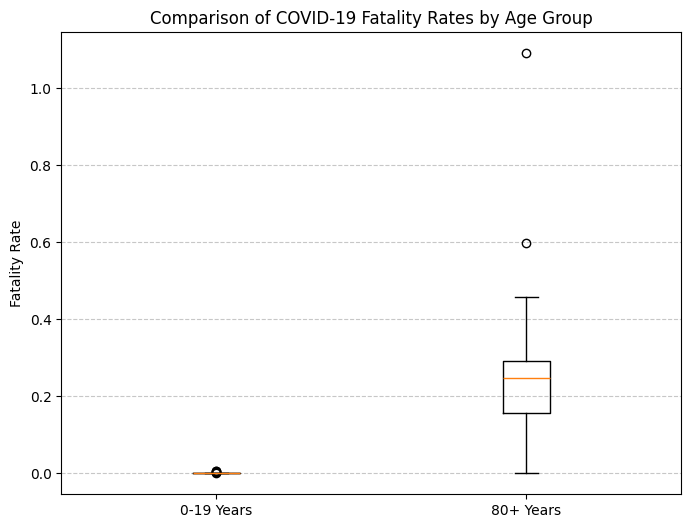

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# 1. 讀取資料集
names = ['place', 'age', 'NoMale', 'NoFemale', 'DNoMale', 'DNoFemale']
dataset = pd.read_csv('data.csv', names=names)

# 2. 篩選 0-19 與 80+ 歲的資料
young = dataset[dataset['age'] == '0-19'].copy()
old = dataset[dataset['age'] == '80+'].copy()

# 3. 計算致死率: (死亡男 + 死亡女) / (確診男 + 確診女)
young['FatalityRate'] = (young['DNoMale'] + young['DNoFemale']) / (young['NoMale'] + young['NoFemale'])
old['FatalityRate'] = (old['DNoMale'] + old['DNoFemale']) / (old['NoMale'] + old['NoFemale'])

# 排除缺失值 (NaN) 以確保計算正確
rate_young = young['FatalityRate'].dropna()
rate_old = old['FatalityRate'].dropna()

# 4. 計算平均數與標準差
mean_young = rate_young.mean()
std_young = rate_young.std()
mean_old = rate_old.mean()
std_old = rate_old.std()

print("=== 描述性統計 (放入 Report 第 2 部分) ===")
print(f"0-19歲組 - 平均致死率 (Mean): {mean_young:.6f}, 標準差 (Std): {std_young:.6f}")
print(f"80+歲組  - 平均致死率 (Mean): {mean_old:.6f}, 標準差 (Std): {std_old:.6f}")

# 5. 進行雙樣本 t 檢定
# 講義中有提到兩組變異數不同，因此這裡設定 equal_var=False (Welch's t-test)
t_stat, p_val = ttest_ind(rate_old, rate_young, equal_var=False)

print("\n=== 假設檢定結果 (放入 Report 第 3 & 4 部分) ===")
print(f"T-statistic (t 值): {t_stat:.4f}")
print(f"P-value (p 值): {p_val:.4e}")

# 6. 繪製並儲存箱型圖
plt.figure(figsize=(8, 6))
plt.boxplot([rate_young, rate_old], labels=['0-19 Years', '80+ Years'])
plt.title('Comparison of COVID-19 Fatality Rates by Age Group')
plt.ylabel('Fatality Rate')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 儲存成圖片檔案，方便你放進 Word 報告裡
plt.savefig('fatality_boxplot.png')
print("\n箱型圖已經成功儲存為 'fatality_boxplot.png'！")